## **Ejercicio 3. Análisis exploratorio**

---

## **Carga de los datos preparados en el ejercicio 2**

In [1]:
import ast
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import emoji as libreria_emoji
import matplotlib.pyplot as plt
import pandas as pd

SEMILLA = 123

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 170)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "data" / "processed"

COLUMNAS_LISTA_COMENTARIOS = ["urls", "hashtags", "menciones", "emojis"]
COLUMNAS_LISTA_VIDEOS = ["query_hits", "keywords"]


def a_lista(valor):
    if isinstance(valor, str) and valor.startswith("["):
        return ast.literal_eval(valor)
    return []


comentarios = pd.read_csv(DIR_PROCESSED / "comentarios_limpio.csv", keep_default_na=False)
videos = pd.read_csv(DIR_PROCESSED / "videos_limpio.csv", keep_default_na=False)

for col in COLUMNAS_LISTA_COMENTARIOS:
    comentarios[col] = comentarios[col].map(a_lista)
for col in COLUMNAS_LISTA_VIDEOS:
    videos[col] = videos[col].map(a_lista)

comentarios["me_gusta"] = pd.to_numeric(comentarios.me_gusta)
comentarios["respuestas"] = pd.to_numeric(comentarios.respuestas)
comentarios["es_respuesta"] = comentarios.es_respuesta.astype(str) == "True"
videos["vistas"] = pd.to_numeric(videos.vistas)

titulo = videos.set_index("video_id").title.to_dict()
canal_por_video = videos.set_index("video_id").channel_name.to_dict()

print(f"[cargado]  comentarios_limpio.csv -> {comentarios.shape[0]} filas, {comentarios.shape[1]} columnas")
print(f"[cargado]  videos_limpio.csv      -> {videos.shape[0]} filas, {videos.shape[1]} columnas")

[cargado]  comentarios_limpio.csv -> 406 filas, 17 columnas
[cargado]  videos_limpio.csv      -> 293 filas, 15 columnas


In [2]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_SUAVE, REJILLA = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": REJILLA,
    "axes.labelcolor": TINTA_SUAVE,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": TINTA,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": REJILLA,
    "grid.linewidth": 0.6,
    "xtick.color": TINTA_SUAVE,
    "ytick.color": TINTA_SUAVE,
    "font.size": 9,
    "legend.frameon": False,
})


def rejilla(ax, eje="x"):
    ax.grid(axis=eje, zorder=0)
    ax.set_axisbelow(True)

---

## **3.1. Descriptivos mínimos del conjunto**

In [3]:
print("CONTEOS GENERALES")
print(f"  videos en el catalogo             : {videos.video_id.nunique()}")
print(f"  canales                           : {videos.channel_id.nunique()}")
print(f"  comentarios                       : {len(comentarios)}")
print(f"     de primer nivel                : {int((~comentarios.es_respuesta).sum())}")
print(f"     respuestas                     : {int(comentarios.es_respuesta.sum())}")
print(f"  autores distintos                 : {comentarios.author_channel_id.nunique()}")
print(f"  videos con al menos un comentario : {comentarios.video_id.nunique()}")
print(f"  canales con al menos un comentario: {videos[videos.video_id.isin(comentarios.video_id)].channel_id.nunique()}")

CONTEOS GENERALES
  videos en el catalogo             : 293
  canales                           : 97
  comentarios                       : 406
     de primer nivel                : 370
     respuestas                     : 36
  autores distintos                 : 332
  videos con al menos un comentario : 19
  canales con al menos un comentario: 8


In [4]:
videos_por_canal = videos.groupby("channel_id").size()
comentarios_por_video = comentarios.groupby("video_id").size()
autores_por_video = comentarios.groupby("video_id").author_channel_id.nunique()
comentarios_por_autor = comentarios.groupby("author_channel_id").size()

print("VIDEOS POR CANAL")
print(videos_por_canal.describe().round(2).to_string())
print(f"  canales con un solo video: {int((videos_por_canal == 1).sum())} de {len(videos_por_canal)}")
print()
print("COMENTARIOS Y AUTORES POR VIDEO (los 19 con participacion)")
print(pd.DataFrame({"comentarios": comentarios_por_video, "autores": autores_por_video}).describe().round(2).to_string())
print()
print("COMENTARIOS POR AUTOR")
print(comentarios_por_autor.describe().round(2).to_string())
for n, cuantos in comentarios_por_autor.value_counts().sort_index().items():
    print(f"    {n} comentario(s): {cuantos} autores")

VIDEOS POR CANAL
count    97.00
mean      3.02
std       5.14
min       1.00
25%       1.00
50%       1.00
75%       2.00
max      32.00
  canales con un solo video: 65 de 97

COMENTARIOS Y AUTORES POR VIDEO (los 19 con participacion)
       comentarios  autores
count        19.00    19.00
mean         21.37    18.05
std          36.82    29.46
min           1.00     1.00
25%           2.50     2.50
50%           7.00     7.00
75%          25.00    18.50
max         161.00   128.00

COMENTARIOS POR AUTOR
count    332.00
mean       1.22
std        0.68
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        6.00
    1 comentario(s): 286 autores
    2 comentario(s): 30 autores
    3 comentario(s): 10 autores
    4 comentario(s): 2 autores
    5 comentario(s): 2 autores
    6 comentario(s): 2 autores


In [5]:
print("VISUALIZACIONES (los 293 videos)")
print(videos.vistas.describe().round(1).to_string())
print()
print("VISUALIZACIONES (los 19 videos con comentarios)")
print(videos[videos.video_id.isin(comentarios.video_id)].vistas.describe().round(1).to_string())
print()
print("RESPUESTAS DECLARADAS POR COMENTARIO")
print(comentarios.respuestas.describe().round(2).to_string())
print(f"  comentarios con al menos una respuesta: {int((comentarios.respuestas > 0).sum())}")
print()
print("ME GUSTA POR COMENTARIO")
print(comentarios.me_gusta.describe().round(2).to_string())
print(f"  comentarios con al menos un me gusta : {int((comentarios.me_gusta > 0).sum())}")
print(f"  me gusta acumulados                  : {int(comentarios.me_gusta.sum())}")

VISUALIZACIONES (los 293 videos)
count        293.0
mean       60430.1
std       515798.3
min            2.0
25%          215.0
50%         1175.0
75%         7465.0
max      8190449.0

VISUALIZACIONES (los 19 videos con comentarios)
count        19.0
mean      20046.1
std       68934.2
min          52.0
25%         695.0
50%        1954.0
75%        8424.0
max      304089.0

RESPUESTAS DECLARADAS POR COMENTARIO
count    406.00
mean       0.13
std        0.58
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        7.00
  comentarios con al menos una respuesta: 30

ME GUSTA POR COMENTARIO
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00
  comentarios con al menos un me gusta : 217
  me gusta acumulados                  : 2325


In [6]:
print("CATEGORIAS DEL CATALOGO COMPLETO")
print(videos.category.value_counts().to_string())
print()
print("CATEGORIAS DE LOS VIDEOS QUE RECIBIERON COMENTARIOS")
print(videos[videos.video_id.isin(comentarios.video_id)].category.value_counts().to_string())

CATEGORIAS DEL CATALOGO COMPLETO
category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1

CATEGORIAS DE LOS VIDEOS QUE RECIBIERON COMENTARIOS
category
News & Politics          16
Entertainment             2
Nonprofits & Activism     1


In [7]:
print("CONSULTAS DE BUSQUEDA (source_query)")
print(videos.source_query.value_counts().to_string())
print()
print("ESTRATEGIA DE BUSQUEDA (source_group)")
print(videos.source_group.value_counts().to_string())
print()
consultas_por_video = videos.query_hits.str.len()
print("CONSULTAS QUE RECUPERARON CADA VIDEO (query_hits)")
print(consultas_por_video.describe().round(2).to_string())
print(f"  videos recuperados por mas de una consulta: {int((consultas_por_video > 1).sum())}")

CONSULTAS DE BUSQUEDA (source_query)
source_query
Municipalidad de Guatemala                20
@GobiernodelaRepublicadeGuatema           18
Gobierno de Guatemala                     18
@GobiernodeGuatemala                      17
guatemala noticias                        16
@MunicipalidaddeGuatemala-1551            16
Ministerio de Comunicaciones Guatemala    16
Conred Guatemala                          15
Gobierno de la República de Guatemala     15
PMT Guatemala                             15
guatemala trafico                         13
guatemala transporte                      13
Policia Nacional Civil Guatemala          13
Provial Guatemala                         13
guatemala lluvias                         12
guatemala politica                        12
guatemala seguridad                       12
@quorumgt                                 12
Ministerio de Gobernacion Guatemala       12
@quorumgt/videos                          11
Quorum GT                                  4

ESTR

In [8]:
RE_HASHTAG = re.compile(r"#\w+")

hashtags_comentarios = Counter(h.lower() for lista in comentarios.hashtags for h in lista)
hashtags_videos = Counter(
    h.lower() for texto in (videos.title + " " + videos.description) for h in RE_HASHTAG.findall(texto)
)

print(f"HASHTAGS EN COMENTARIOS: {sum(hashtags_comentarios.values())} apariciones, {len(hashtags_comentarios)} distintos")
for h, n in hashtags_comentarios.most_common(5):
    print(f"  {n:3d}  {h}")
print()
print(f"HASHTAGS EN TITULOS Y DESCRIPCIONES: {sum(hashtags_videos.values())} apariciones, {len(hashtags_videos)} distintos")
for h, n in hashtags_videos.most_common(12):
    print(f"  {n:3d}  {h}")

HASHTAGS EN COMENTARIOS: 1 apariciones, 1 distintos
    1  #ineptobran

HASHTAGS EN TITULOS Y DESCRIPCIONES: 588 apariciones, 338 distintos
   48  #guatemala
   29  #larondagt
   14  #noticias
   12  #envivodca
    7  #nacionales
    7  #like
    7  #comenta
    7  #comparte
    7  #siguenos
    6  #protegeryservir
    6  #noticiasguatemala
    5  #pnc


In [9]:
tokens = [t for texto in comentarios.texto_limpio for t in str(texto).split()]
palabras = [t for t in tokens if not libreria_emoji.purely_emoji(t)]
emojis_sueltos = [t for t in tokens if libreria_emoji.purely_emoji(t)]

frec_palabras = Counter(palabras)
frec_emojis = Counter(emojis_sueltos)

print(f"TOKENS EN texto_limpio: {len(tokens)}  (palabras {len(palabras)}, emojis {len(emojis_sueltos)})")
print(f"VOCABULARIO: {len(frec_palabras)} palabras distintas, {len(frec_emojis)} emojis distintos")
print()
print("VEINTICINCO PALABRAS MAS FRECUENTES")
for p, n in frec_palabras.most_common(25):
    print(f"  {n:3d}  {p}")
print()
print("DIEZ EMOJIS MAS FRECUENTES")
for e, n in frec_emojis.most_common(10):
    print(f"  {n:3d}  {e}")

TOKENS EN texto_limpio: 4143  (palabras 3944, emojis 199)
VOCABULARIO: 1965 palabras distintas, 44 emojis distintos

VEINTICINCO PALABRAS MAS FRECUENTES
   57  país
   56  pueblo
   50  guatemala
   49  diputado
   37  pagar
   34  dinero
   34  presidente
   29  corrupto
   28  trabajo
   24  excelente
   22  seguir
   21  trabajar
   20  empresa
   20  sueldo
   18  proyecto
   17  almuerzo
   17  dios
   16  persona
   16  pasar
   16  señor
   16  corrupción
   15  dejar
   15  arévalo
   14  llegar
   14  gobierno

DIEZ EMOJIS MAS FRECUENTES
   29  😂
   19  🇬🇹
   17  👏
   15  🎉
   14  👍
    8  😡
    8  😮
    7  😅
    7  😢
    6  👹


In [10]:
def bigramas(texto):
    """Bigramas dentro de un mismo comentario, ignorando los emojis."""
    palabras_comentario = [t for t in str(texto).split() if not libreria_emoji.purely_emoji(t)]
    return list(zip(palabras_comentario, palabras_comentario[1:]))


frec_bigramas = Counter(b for texto in comentarios.texto_limpio for b in bigramas(texto))

print(f"BIGRAMAS: {sum(frec_bigramas.values())} apariciones, {len(frec_bigramas)} distintos")
print()
print("VEINTE BIGRAMAS MAS FRECUENTES")
for (a, b), n in frec_bigramas.most_common(20):
    print(f"  {n:3d}  {a} {b}")

BIGRAMAS: 3546 apariciones, 3362 distintos

VEINTE BIGRAMAS MAS FRECUENTES
   10  bernardo arévalo
    9  presidente bernardo
    8  morir hambre
    8  ciudad guatemala
    6  pagar sueldo
    5  nery rodas
    5  pueblo pagar
    5  bla bla
    4  diputado alcanzar
    4  gastar dinero
    4  pagar dinero
    4  dinero pueblo
    4  pacto corrupto
    4  excelente video
    4  guatemala saludo
    4  pagar comida
    3  excelente trabajo
    3  busquen trabajo
    3  diputado nery
    3  apoyo presidente


- Videos en el catálogo: 293.
- Canales: 97.
- Comentarios: 406, de los cuales 370 son de primer nivel y 36 son respuestas.
- Autores distintos: 332.
- Videos con al menos un comentario: 19.
- Canales con al menos un comentario: 8.
- Videos por canal: media 3.02, mediana 1, máximo 32; 65 de los 97 canales tienen un solo video.
- Comentarios por video: media 21.37, mediana 7, mínimo 1, máximo 161.
- Autores únicos por video: media 18.05, mediana 7, máximo 128.
- Comentarios por autor: media 1.22, mediana 1, máximo 6; 286 autores comentan una sola vez, 30 lo
  hacen dos veces, 10 tres veces, 2 cuatro veces, 2 cinco veces y 2 seis veces.
- Visualizaciones en el catálogo: media 60,430.1, mediana 1,175, mínimo 2, máximo 8,190,449.
- Visualizaciones en los 19 videos con comentarios: media 20,046.1, mediana 1,954, máximo 304,089.
- Respuestas por comentario: media 0.13, máximo 7; 30 comentarios recibieron al menos una.
- Me gusta por comentario: media 5.73, mediana 1, máximo 405; 217 comentarios recibieron al menos
  uno y el acumulado es de 2,325.
- Categorías en el catálogo: 11, encabezadas por News & Politics con 138 videos, People & Blogs con
  66 y Entertainment con 48.
- Categorías entre los videos comentados: 3, con News & Politics en 16 videos, Entertainment en 2 y
  Nonprofits & Activism en 1.
- Consultas de búsqueda distintas: 21, encabezadas por `Municipalidad de Guatemala` con 20 videos.
- Estrategias de búsqueda: `topic` con 177 videos, `official_gov` con 105 y `channel` con 11.
- Consultas que recuperaron cada video: media 1.02, máximo 2; solo 5 videos fueron recuperados por
  más de una consulta.
- Hashtags en comentarios: 1 aparición y 1 distinto, `#ineptobran`.
- Hashtags en títulos y descripciones de videos: 588 apariciones y 338 distintos, encabezados por
  `#guatemala` con 48 y `#larondagt` con 29.
- Tokens en `texto_limpio`: 4,143, de los cuales 3,944 son palabras y 199 emojis.
- Vocabulario: 1,965 palabras distintas y 44 emojis distintos.
- Palabras más frecuentes: país 57, pueblo 56, guatemala 50, diputado 49, pagar 37, dinero 34,
  presidente 34, corrupto 29, trabajo 28 y excelente 24.
- Emojis más frecuentes: 😂 con 29, 🇬🇹 con 19, 👏 con 17, 🎉 con 15 y 👍 con 14.
- Bigramas: 3,546 apariciones y 3,362 distintos.
- Bigramas más frecuentes: `bernardo arévalo` 10, `presidente bernardo` 9, `morir hambre` 8,
  `ciudad guatemala` 8, `pagar sueldo` 6 y `nery rodas` 5.

---

## **3.2. Concentración de la participación**

In [11]:
def gini(valores):
    """Coeficiente de Gini: 0 es reparto perfectamente igual, 1 es concentracion total."""
    v = sorted(valores)
    n = len(v)
    return sum((2 * i - n + 1) * x for i, x in enumerate(v)) / (n * sum(v))


def concentracion(serie, etiqueta):
    orden = serie.sort_values(ascending=False)
    total = orden.sum()
    print(f"{etiqueta}  (n={len(orden)}, total={total})")
    for k in [1, 3, 5, 10]:
        if k <= len(orden):
            print(f"    los {k:2d} mas activos concentran : {orden.head(k).sum() / total:6.2%}")
    print(f"    coeficiente de Gini            : {gini(orden.tolist()):.3f}")
    print()


concentracion(comentarios_por_video, "COMENTARIOS POR VIDEO")
concentracion(comentarios.groupby("channel_id").size(), "COMENTARIOS POR CANAL DUEÑO DEL VIDEO")
concentracion(comentarios_por_autor, "COMENTARIOS POR AUTOR")
concentracion(videos.vistas[videos.vistas > 0], "VISUALIZACIONES POR VIDEO")

COMENTARIOS POR VIDEO  (n=19, total=406)
    los  1 mas activos concentran : 39.66%
    los  3 mas activos concentran : 63.05%
    los  5 mas activos concentran : 75.37%
    los 10 mas activos concentran : 93.60%
    coeficiente de Gini            : 0.660

COMENTARIOS POR CANAL DUEÑO DEL VIDEO  (n=8, total=406)
    los  1 mas activos concentran : 63.05%
    los  3 mas activos concentran : 86.45%
    los  5 mas activos concentran : 96.06%
    coeficiente de Gini            : 0.664

COMENTARIOS POR AUTOR  (n=332, total=406)
    los  1 mas activos concentran :  1.48%
    los  3 mas activos concentran :  4.19%
    los  5 mas activos concentran :  6.40%
    los 10 mas activos concentran : 10.34%
    coeficiente de Gini            : 0.164

VISUALIZACIONES POR VIDEO  (n=293, total=17706015)
    los  1 mas activos concentran : 46.26%
    los  3 mas activos concentran : 68.30%
    los  5 mas activos concentran : 73.54%
    los 10 mas activos concentran : 82.03%
    coeficiente de Gini          

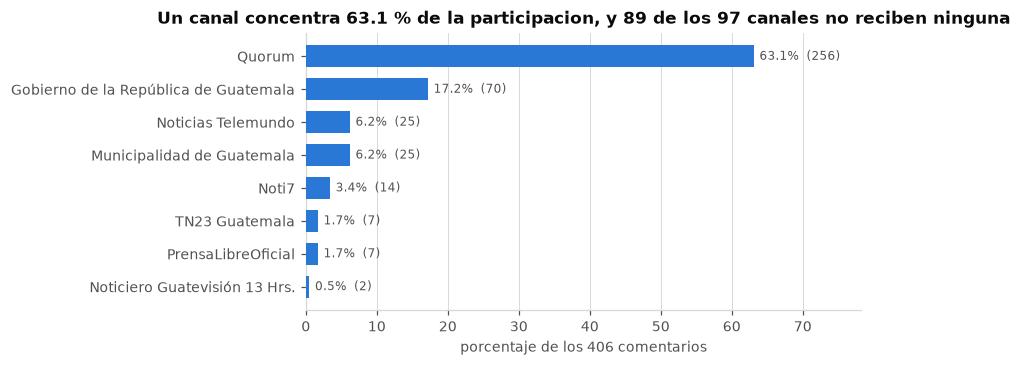

In [12]:
canales_activos = (
    comentarios.merge(videos[["video_id", "channel_name"]], on="video_id", how="left")
    .groupby("channel_name")
    .agg(comentarios=("comment_id", "size"),
         autores=("author_channel_id", "nunique"),
         videos=("video_id", "nunique"))
    .sort_values("comentarios", ascending=False)
)
canales_activos["pct_comentarios"] = (100 * canales_activos.comentarios / len(comentarios)).round(1)

por_canal = canales_activos.sort_values("pct_comentarios")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(por_canal.index, por_canal.pct_comentarios, color=AZUL, height=0.66, zorder=3)
for y, (pct, n) in enumerate(zip(por_canal.pct_comentarios, por_canal.comentarios)):
    ax.text(pct + 0.8, y, f"{pct}%  ({n})", va="center", fontsize=8, color=TINTA_SUAVE)
rejilla(ax)
ax.set_xlim(0, por_canal.pct_comentarios.max() * 1.24)
ax.set_xlabel("porcentaje de los 406 comentarios")
ax.set_title("Un canal concentra 63.1 % de la participacion, y 89 de los 97 canales no reciben ninguna")
plt.tight_layout()
plt.show()

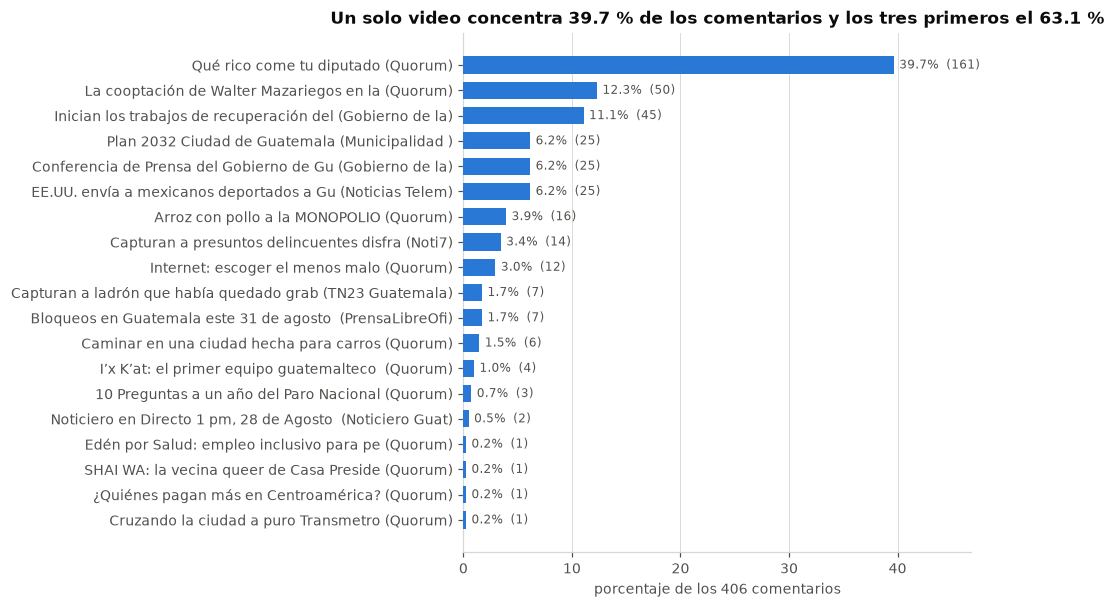

In [13]:
pct_por_video = (100 * comentarios_por_video / len(comentarios)).sort_values()
etiquetas_video = [f"{titulo[v][:40]} ({canal_por_video[v][:14]})" for v in pct_por_video.index]

fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(etiquetas_video, pct_por_video.values, color=AZUL, height=0.68, zorder=3)
for y, (pct, v) in enumerate(zip(pct_por_video.values, pct_por_video.index)):
    ax.text(pct + 0.5, y, f"{pct:.1f}%  ({comentarios_por_video[v]})", va="center",
            fontsize=8, color=TINTA_SUAVE)
rejilla(ax)
ax.set_xlim(0, pct_por_video.max() * 1.18)
ax.set_xlabel("porcentaje de los 406 comentarios")
ax.set_title("Un solo video concentra 39.7 % de los comentarios y los tres primeros el 63.1 %")
plt.tight_layout()
plt.show()

---

## **3.3. Popularidad frente a participación**

In [14]:
comparacion = videos[["video_id", "channel_name", "title", "vistas"]].copy()
comparacion["comentarios"] = comparacion.video_id.map(comentarios_por_video).fillna(0).astype(int)
comparacion["autores"] = comparacion.video_id.map(autores_por_video).fillna(0).astype(int)
comparacion["me_gusta"] = comparacion.video_id.map(comentarios.groupby("video_id").me_gusta.sum()).fillna(0).astype(int)
comparacion["respuestas"] = comparacion.video_id.map(comentarios.groupby("video_id").respuestas.sum()).fillna(0).astype(int)
comparacion["interacciones"] = comparacion.comentarios + comparacion.me_gusta + comparacion.respuestas

con_participacion = comparacion[comparacion.comentarios > 0]

print("CORRELACION ENTRE VISUALIZACIONES Y COMENTARIOS")
print(f"  sobre los 293 videos del catalogo   -> Pearson {comparacion.vistas.corr(comparacion.comentarios):.3f}, "
      f"Spearman {comparacion.vistas.corr(comparacion.comentarios, method='spearman'):.3f}")
print(f"  sobre los {len(con_participacion)} videos con comentarios -> Pearson {con_participacion.vistas.corr(con_participacion.comentarios):.3f}, "
      f"Spearman {con_participacion.vistas.corr(con_participacion.comentarios, method='spearman'):.3f}")
print()
print("COMENTARIOS POR CADA MIL VISUALIZACIONES (videos con participacion)")
print((1000 * con_participacion.comentarios / con_participacion.vistas).describe().round(3).to_string())

CORRELACION ENTRE VISUALIZACIONES Y COMENTARIOS


  sobre los 293 videos del catalogo   -> Pearson -0.008, Spearman 0.080
  sobre los 19 videos con comentarios -> Pearson 0.067, Spearman 0.811

COMENTARIOS POR CADA MIL VISUALIZACIONES (videos con participacion)
count    19.000
mean      5.900
std       5.823
min       0.082
25%       1.639
50%       3.856
75%       7.540
max      19.231


In [15]:
def limitacion(fila):
    """Nota de lectura para cada fila, segun la relacion entre visibilidad y participacion."""
    if fila.comentarios == 0:
        return "Sin comentarios recolectados; la ausencia es de la muestra, no del video"
    tasa = 1000 * fila.comentarios / fila.vistas
    if tasa < 1:
        return "Visibilidad alta frente a su participacion; conteos de un solo momento"
    if tasa > 10:
        return "Participacion alta frente a su visibilidad; base de vistas pequeña"
    return "Vistas y comentarios capturados en momentos distintos; sin fecha del comentario"


tabla_popularidad = pd.concat([
    con_participacion.sort_values("comentarios", ascending=False),
    comparacion[comparacion.comentarios == 0].nlargest(6, "vistas"),
])
tabla_popularidad = tabla_popularidad.assign(
    video=lambda d: d.title.str.slice(0, 52),
    canal=lambda d: d.channel_name.str.slice(0, 24),
    limitaciones=lambda d: d.apply(limitacion, axis=1),
)[["video", "canal", "vistas", "comentarios", "interacciones", "limitaciones"]].reset_index(drop=True)

tabla_popularidad

,video,canal,vistas,comentarios,interacciones,limitaciones
0,Qué rico come tu diputado,Quorum,11775,161,522,Participacion alta frente a su visibilidad; ba...
1,La cooptación de Walter Mazariegos en la USAC,Quorum,10156,50,141,Vistas y comentarios capturados en momentos di...
2,Inician los trabajos de recuperación del Puent...,Gobierno de la República,11670,45,146,Vistas y comentarios capturados en momentos di...
3,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,14200,25,63,Vistas y comentarios capturados en momentos di...
4,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República,3628,25,49,Vistas y comentarios capturados en momentos di...
5,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatema,304089,25,1738,Visibilidad alta frente a su participacion; co...
6,Arroz con pollo a la MONOPOLIO,Quorum,1954,16,29,Vistas y comentarios capturados en momentos di...
7,Capturan a presuntos delincuentes disfrazados ...,Noti7,6692,14,27,Vistas y comentarios capturados en momentos di...
8,Internet: escoger el menos malo,Quorum,717,12,16,Participacion alta frente a su visibilidad; ba...
9,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,5469,7,9,Vistas y comentarios capturados en momentos di...


---

## **3.4. Visualizaciones**

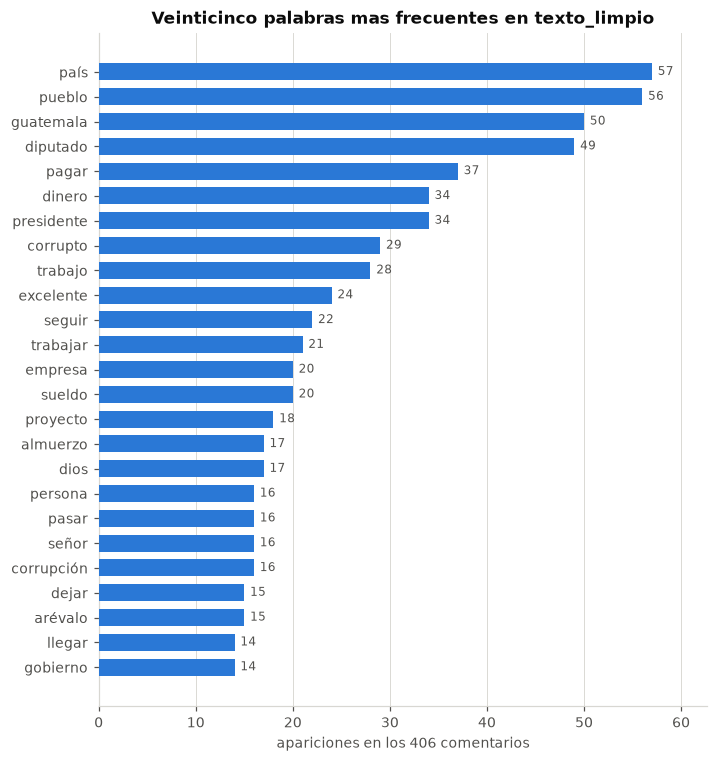

In [16]:
palabras_top = frec_palabras.most_common(25)[::-1]
etiquetas = [p for p, _ in palabras_top]
valores = [n for _, n in palabras_top]

fig, ax = plt.subplots(figsize=(6.6, 7))
ax.barh(etiquetas, valores, color=AZUL, height=0.68, zorder=3)
for y, valor in enumerate(valores):
    ax.text(valor + 0.6, y, str(valor), va="center", fontsize=8, color=TINTA_SUAVE)
rejilla(ax)
ax.set_xlim(0, max(valores) * 1.1)
ax.set_xlabel("apariciones en los 406 comentarios")
ax.set_title("Veinticinco palabras mas frecuentes en texto_limpio")
plt.tight_layout()
plt.show()

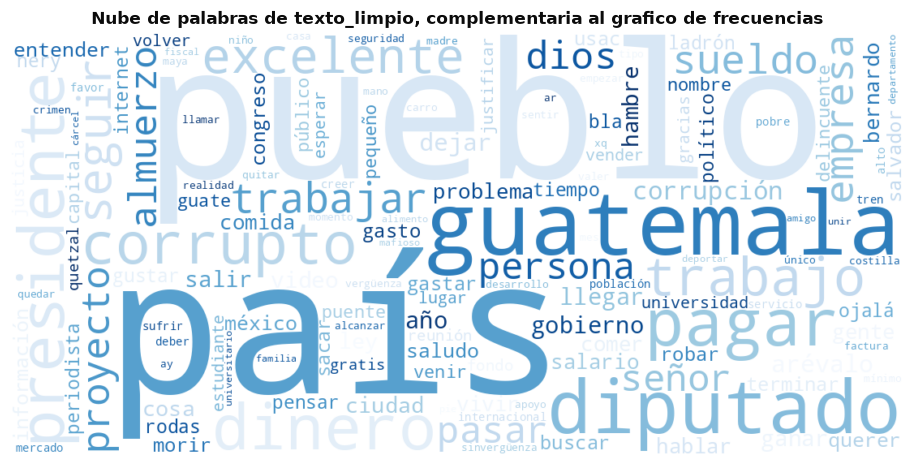

In [17]:
from wordcloud import WordCloud

nube = WordCloud(
    width=1100, height=520, background_color="white",
    colormap="Blues", prefer_horizontal=0.95,
    max_words=140, random_state=SEMILLA,
).generate_from_frequencies(frec_palabras)

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.imshow(nube, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras de texto_limpio, complementaria al grafico de frecuencias")
plt.tight_layout()
plt.show()

---

## **3.5. Preguntas obligatorias**

### **¿Qué videos y canales concentran la mayor participación observada?**

In [18]:
print("CINCO VIDEOS MAS COMENTADOS")
for _, f in comparacion.nlargest(5, "comentarios").iterrows():
    print(f"  {f.comentarios:4d} comentarios ({f.comentarios / len(comentarios):5.1%})  "
          f"{f.channel_name[:22]:24s} {f.title[:44]}")
print()
print("CANALES POR PARTICIPACION RECIBIDA")
for nombre_canal, fila in canales_activos.iterrows():
    print(f"  {int(fila.comentarios):4d} comentarios ({fila.pct_comentarios:4.1f}%)  "
          f"{int(fila.autores):3d} autores  {int(fila.videos)} video(s)  {nombre_canal}")

CINCO VIDEOS MAS COMENTADOS
   161 comentarios (39.7%)  Quorum                   Qué rico come tu diputado
    50 comentarios (12.3%)  Quorum                   La cooptación de Walter Mazariegos en la USA
    45 comentarios (11.1%)  Gobierno de la Repúbli   Inician los trabajos de recuperación del Pue
    25 comentarios ( 6.2%)  Noticias Telemundo       EE.UU. envía a mexicanos deportados a Guatem
    25 comentarios ( 6.2%)  Gobierno de la Repúbli   Conferencia de Prensa del Gobierno de Guatem

CANALES POR PARTICIPACION RECIBIDA
   256 comentarios (63.1%)  214 autores  11 video(s)  Quorum
    70 comentarios (17.2%)   50 autores  2 video(s)  Gobierno de la República de Guatemala
    25 comentarios ( 6.2%)   25 autores  1 video(s)  Municipalidad de Guatemala
    25 comentarios ( 6.2%)   18 autores  1 video(s)  Noticias Telemundo
    14 comentarios ( 3.4%)   13 autores  1 video(s)  Noti7
     7 comentarios ( 1.7%)    7 autores  1 video(s)  PrensaLibreOficial
     7 comentarios ( 1.7%)    

El canal Quorum concentra el 63.1 % de los comentarios con 11 videos, y un solo video suyo, *Qué rico
come tu diputado*, reúne por sí mismo el 39.7 % de toda la participación observada.

### **¿Existen audiencias compartidas entre videos, canales o temas?**

In [19]:
videos_por_autor = comentarios.groupby("author_channel_id").video_id.apply(set)

compartidos = Counter()
for conjunto in videos_por_autor:
    for a, b in combinations(sorted(conjunto), 2):
        compartidos[(a, b)] += 1

print(f"PARES DE VIDEOS QUE COMPARTEN AL MENOS UN AUTOR: {len(compartidos)} de {19 * 18 // 2} posibles")
for (a, b), n in compartidos.most_common():
    print(f"  {n} autor(es): {titulo[a][:38]}  <->  {titulo[b][:38]}")
print()

con_canal = comentarios.merge(videos[["video_id", "channel_name", "category"]], on="video_id", how="left")
for columna, etiqueta in [("channel_name", "CANALES"), ("category", "CATEGORIAS")]:
    pares = Counter()
    for _, grupo in con_canal.groupby("author_channel_id"):
        for a, b in combinations(sorted(set(grupo[columna])), 2):
            pares[(a, b)] += 1
    print(f"AUDIENCIAS COMPARTIDAS ENTRE {etiqueta}: {len(pares)} pares")
    for (a, b), n in pares.most_common():
        print(f"  {n} autor(es): {a} <-> {b}")
    print()

PARES DE VIDEOS QUE COMPARTEN AL MENOS UN AUTOR: 11 de 171 posibles
  2 autor(es): Internet: escoger el menos malo  <->  Arroz con pollo a la MONOPOLIO
  2 autor(es): La cooptación de Walter Mazariegos en   <->  Qué rico come tu diputado
  1 autor(es): Conferencia de Prensa del Gobierno de   <->  Qué rico come tu diputado
  1 autor(es): Capturan a ladrón que había quedado gr  <->  La cooptación de Walter Mazariegos en 
  1 autor(es): Capturan a presuntos delincuentes disf  <->  Inician los trabajos de recuperación d
  1 autor(es): La cooptación de Walter Mazariegos en   <->  Internet: escoger el menos malo
  1 autor(es): Qué rico come tu diputado  <->  Internet: escoger el menos malo
  1 autor(es): Bloqueos en Guatemala este 31 de agost  <->  Qué rico come tu diputado
  1 autor(es): Caminar en una ciudad hecha para carro  <->  Internet: escoger el menos malo
  1 autor(es): Caminar en una ciudad hecha para carro  <->  Arroz con pollo a la MONOPOLIO
  1 autor(es): Inician los trabajos de

Sí existen, pero son mínimas: solo 11 de los 171 pares posibles de videos comparten algún autor, y
entre canales distintos apenas 4 pares, de tal forma que cada video funciona casi como una audiencia
aislada.

### **¿Qué autores funcionan como puentes entre contenidos?**

In [20]:
autores_recurrentes = (
    comentarios.groupby(["author_channel_id", "author_name"])
    .agg(comentarios=("comment_id", "size"), videos=("video_id", "nunique"))
    .sort_values(["videos", "comentarios"], ascending=False)
)
puentes = autores_recurrentes[autores_recurrentes.videos > 1].copy()
puentes["canales"] = puentes.index.get_level_values(0).map(
    lambda a: len({canal_por_video[v] for v in videos_por_autor[a]})
)
puentes["contenidos"] = puentes.index.get_level_values(0).map(
    lambda a: " | ".join(sorted(titulo[v][:30] for v in videos_por_autor[a]))
)

print(f"AUTORES EN MAS DE UN VIDEO: {len(puentes)} de {comentarios.author_channel_id.nunique()} "
      f"({len(puentes) / comentarios.author_channel_id.nunique():.1%})")
print(f"DE ESOS, LOS QUE CRUZAN DOS CANALES: {int((puentes.canales > 1).sum())}")
puentes[["comentarios", "videos", "canales", "contenidos"]]

AUTORES EN MAS DE UN VIDEO: 9 de 332 (2.7%)
DE ESOS, LOS QUE CRUZAN DOS CANALES: 4


,,comentarios,videos,canales,contenidos
author_channel_id,author_name,,,,
UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1,Arroz con pollo a la MONOPOLIO | Caminar en un...
UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,1,Internet: escoger el menos mal | La cooptación...
UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2,2,Conferencia de Prensa del Gobi | Qué rico come...
UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2,1,La cooptación de Walter Mazari | Qué rico come...
UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1,Arroz con pollo a la MONOPOLIO | Internet: esc...
UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,2,Capturan a ladrón que había qu | La cooptación...
UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,Capturan a presuntos delincuen | Inician los t...
UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,Bloqueos en Guatemala este 31 | Qué rico come...
UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1,Conferencia de Prensa del Gobi | Inician los t...


Solo 9 autores de 332 aparecen en más de un video y apenas 4 de ellos cruzan canales distintos, por
lo que los puentes reales son `@virgiliogarcia3039`, `@MarcosCarillo-b1r`, `@franciscoflores3120` y
`@moisesvaldez4043`.

### **¿Qué temas caracterizan a las principales comunidades de participación?**

In [21]:
for vid, n in comentarios_por_video.sort_values(ascending=False).head(6).items():
    tokens_video = [
        t for texto in comentarios[comentarios.video_id == vid].texto_limpio
        for t in str(texto).split() if not libreria_emoji.purely_emoji(t)
    ]
    print(f"[{n:3d} comentarios] {canal_por_video[vid][:20]:22s} {titulo[vid][:44]}")
    print(f"    {', '.join(p for p, _ in Counter(tokens_video).most_common(10))}")
    print()

[161 comentarios] Quorum                 Qué rico come tu diputado
    pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo, trabajar, corrupto, país

[ 50 comentarios] Quorum                 La cooptación de Walter Mazariegos en la USA
    corrupto, usac, estudiante, universidad, excelente, información, video, universitario, seguir, pueblo

[ 45 comentarios] Gobierno de la Repúb   Inician los trabajos de recuperación del Pue
    presidente, país, año, arévalo, proyecto, bernardo, guatemala, terminar, puente, corrupto

[ 25 comentarios] Noticias Telemundo     EE.UU. envía a mexicanos deportados a Guatem
    país, deportar, you, entrar, méxico, if, to, persona, pasar, mexicano

[ 25 comentarios] Gobierno de la Repúb   Conferencia de Prensa del Gobierno de Guatem
    país, guatemala, gobierno, bla, presidente, señor, persona, maya, méxico, salvador

[ 25 comentarios] Municipalidad de Gua   Plan 2032 Ciudad de Guatemala
    guatemala, ciudad, proyecto, saludo, vivir, tiempo, dios, o

Cada video sostiene su propio tema sin mezclarse con los demás, y el eje común entre los más
comentados es el gasto público y la corrupción, con palabras como diputado, sueldo, dinero, pueblo y
corrupto. El componente de sentimiento de esta pregunta se aborda en el ejercicio 9, que es donde se
aplica el modelo.

### **¿La visibilidad medida mediante visualizaciones coincide con la participación observada?**

In [22]:
print(f"Spearman sobre los 293 videos              : {comparacion.vistas.corr(comparacion.comentarios, method='spearman'):.3f}")
print(f"Spearman sobre los 19 videos con comentarios: {con_participacion.vistas.corr(con_participacion.comentarios, method='spearman'):.3f}")
print()
mas_vistos = comparacion.nlargest(10, "vistas")
mas_comentados = comparacion.nlargest(10, "comentarios")
print(f"Videos presentes en el top diez de vistas y en el top diez de comentarios: "
      f"{len(set(mas_vistos.index) & set(mas_comentados.index))}")
print()
print("LOS CINCO VIDEOS MAS VISTOS DEL CATALOGO")
print(mas_vistos.head(5)[["channel_name", "vistas", "comentarios"]].to_string(index=False))

Spearman sobre los 293 videos              : 0.080
Spearman sobre los 19 videos con comentarios: 0.811

Videos presentes en el top diez de vistas y en el top diez de comentarios: 1

LOS CINCO VIDEOS MAS VISTOS DEL CATALOGO
    channel_name  vistas  comentarios
Luisito Comunica 8190449            0
      De todo Gt 3152619            0
El Mapa de Sebas  749356            0
      De todo Gt  504374            0
      De todo Gt  424874            0


No coincide: sobre el catálogo completo la correlación es prácticamente nula, los cinco videos más
vistos no tienen ningún comentario recolectado, y solo un video aparece a la vez en el top diez de
vistas y en el de comentarios.

### **¿Qué conclusiones están limitadas por el procedimiento de recolección?**

In [23]:
print(f"cobertura de comentarios  : {comentarios.video_id.nunique()} de {len(videos)} videos ({comentarios.video_id.nunique() / len(videos):.2%})")
print(f"canales representados     : {canales_activos.shape[0]} de {videos.channel_id.nunique()}")
print(f"aporte del canal dominante: {canales_activos.pct_comentarios.max():.1f}%")
print()
print(f"respuestas declaradas por reply_count : {int(comentarios[~comentarios.es_respuesta].respuestas.sum())}")
print(f"respuestas presentes como fila        : {int(comentarios.es_respuesta.sum())}")
print(f"respuestas ausentes del conjunto      : {int(comentarios[~comentarios.es_respuesta].respuestas.sum() - comentarios.es_respuesta.sum())}")
print()
print("ORIGEN DE LOS VIDEOS SEGUN LA ESTRATEGIA DE BUSQUEDA")
print(videos.source_group.value_counts().to_string())
print()
print(f"videos recuperados por mas de una consulta: {int(consultas_por_video.gt(1).sum())} de {len(videos)}")
print(f"fechas absolutas en comentarios          : ninguna, published_text es relativo")

cobertura de comentarios  : 19 de 293 videos (6.48%)
canales representados     : 8 de 97
aporte del canal dominante: 63.1%

respuestas declaradas por reply_count : 51
respuestas presentes como fila        : 36
respuestas ausentes del conjunto      : 15

ORIGEN DE LOS VIDEOS SEGUN LA ESTRATEGIA DE BUSQUEDA
source_group
topic           177
official_gov    105
channel          11

videos recuperados por mas de una consulta: 5 de 293
fechas absolutas en comentarios          : ninguna, published_text es relativo


Queda limitada cualquier conclusión sobre la población de YouTube en Guatemala, ya que la
participación observada cubre el 6.48 % de los videos, proviene de 8 de 97 canales, depende de 21
consultas elegidas de antemano y le faltan 15 respuestas que el propio conjunto declara.

---

## **3.6. Preguntas adicionales**

### **¿Hay relación entre el video más comentado y su temática?**

In [24]:
TERMINOS_CONFRONTACION = {
    "corrupto", "corrupción", "ladrón", "robar", "mentira", "sinvergüenza", "descarado",
    "vergüenza", "estafa", "rata", "impunidad", "sinvergüenzada", "cinico", "ratero",
}


def tasa_confrontacion(vid):
    textos = comentarios[comentarios.video_id == vid].texto_limpio
    con_termino = sum(1 for t in textos if TERMINOS_CONFRONTACION & set(str(t).split()))
    return 100 * con_termino / len(textos)


resumen_tema = pd.DataFrame({
    "comentarios": comentarios_por_video,
    "pct_confrontacion": [round(tasa_confrontacion(v), 1) for v in comentarios_por_video.index],
    "categoria": [videos.set_index("video_id").category[v] for v in comentarios_por_video.index],
    "titulo": [titulo[v][:52] for v in comentarios_por_video.index],
}).sort_values("comentarios", ascending=False)

print(f"tasa de confrontacion en el conjunto completo: {100 * sum(1 for t in comentarios.texto_limpio if TERMINOS_CONFRONTACION & set(str(t).split())) / len(comentarios):.1f}%")
print()
resumen_tema

tasa de confrontacion en el conjunto completo: 15.5%



,comentarios,pct_confrontacion,categoria,titulo
video_id,,,,
n8iP75gIpmw,161,22.4,News & Politics,Qué rico come tu diputado
j43HgwYFKfk,50,16.0,News & Politics,La cooptación de Walter Mazariegos en la USAC
6W4u8sGEnGM,45,22.2,Entertainment,Inician los trabajos de recuperación del Puent...
OkXlHx0hx-8,25,4.0,News & Politics,EE.UU. envía a mexicanos deportados a Guatemal...
PjmxCj-a9Hg,25,16.0,Entertainment,Conferencia de Prensa del Gobierno de Guatemal...
lj983NWyAQY,25,0.0,News & Politics,Plan 2032 Ciudad de Guatemala
yLZS3JiEBg8,16,0.0,News & Politics,Arroz con pollo a la MONOPOLIO
06mFNPU0aB8,14,0.0,News & Politics,Capturan a presuntos delincuentes disfrazados ...
ndAZjHqzzT8,12,8.3,News & Politics,Internet: escoger el menos malo


Sí la hay: los tres videos más comentados tratan gasto público, corrupción universitaria y obra
pública, y el más comentado alcanza un 22.4 % de comentarios con vocabulario confrontativo frente al
15.5 % del conjunto, aunque la tasa más alta la tiene un video de nota roja con solo 7 comentarios.

### **¿Cuál es la duración de los videos que más me gusta tienen?**

In [25]:
COLUMNAS_ESPERADAS = ["duracion", "duration", "length", "video_likes", "like_count"]

print("BUSQUEDA DE LAS VARIABLES QUE PIDE LA PREGUNTA")
print(f"  columnas disponibles en videos: {list(videos.columns)}")
print(f"  columnas de duracion presentes: {[c for c in COLUMNAS_ESPERADAS if c in videos.columns]}")
print(f"  columnas de me gusta del video: {[c for c in videos.columns if 'gusta' in c or 'like' in c]}")
print()
print("SUSTITUTO DISPONIBLE: antiguedad del video a partir de publish_date")

videos["publicado"] = pd.to_datetime(videos.publish_date, format="ISO8601", utc=True, errors="coerce")
videos["antiguedad_dias"] = (videos.publicado.max() - videos.publicado).dt.days

antiguedad = comparacion.merge(videos[["video_id", "antiguedad_dias"]], on="video_id", how="left")
con_me_gusta = antiguedad[antiguedad.comentarios > 0]

print()
print(f"  correlacion Spearman entre antiguedad y me gusta acumulados: "
      f"{con_me_gusta.antiguedad_dias.corr(con_me_gusta.me_gusta, method='spearman'):.3f}")
print()
print("CINCO VIDEOS CON MAS ME GUSTA ACUMULADOS EN SUS COMENTARIOS")
print(con_me_gusta.nlargest(5, "me_gusta")[["channel_name", "me_gusta", "comentarios", "antiguedad_dias", "title"]]
      .to_string(index=False, max_colwidth=40))

BUSQUEDA DE LAS VARIABLES QUE PIDE LA PREGUNTA
  columnas disponibles en videos: ['video_id', 'channel_id', 'channel_name', 'handle_canal', 'title', 'category', 'source_query', 'source_group', 'query_hits', 'keywords', 'description', 'vistas', 'vistas_texto', 'publish_date', 'published_time']
  columnas de duracion presentes: []
  columnas de me gusta del video: []

SUSTITUTO DISPONIBLE: antiguedad del video a partir de publish_date

  correlacion Spearman entre antiguedad y me gusta acumulados: 0.413

CINCO VIDEOS CON MAS ME GUSTA ACUMULADOS EN SUS COMENTARIOS
                         channel_name  me_gusta  comentarios  antiguedad_dias                                    title
           Municipalidad de Guatemala      1697           25             2742            Plan 2032 Ciudad de Guatemala
                               Quorum       358          161              735                Qué rico come tu diputado
                               Quorum        91           50              7

No se puede responder tal como está planteada: el conjunto no trae ninguna variable de duración ni
de "me gusta" del video, solo los "me gusta" de cada comentario. Con el sustituto disponible, que es
la antigüedad del video, la correlación con los "me gusta" acumulados es moderada, de 0.413.

### **¿Los videos más comentados son los que más me gusta tienen?**

In [26]:
ranking = con_participacion.assign(
    rango_comentarios=con_participacion.comentarios.rank(ascending=False, method="min").astype(int),
    rango_me_gusta=con_participacion.me_gusta.rank(ascending=False, method="min").astype(int),
)
ranking["desajuste"] = (ranking.rango_comentarios - ranking.rango_me_gusta).abs()

print(f"correlacion Spearman entre comentarios y me gusta acumulados: "
      f"{con_participacion.comentarios.corr(con_participacion.me_gusta, method='spearman'):.3f}")
print(f"me gusta por comentario, media por video: "
      f"{(con_participacion.me_gusta / con_participacion.comentarios).mean():.2f}")
print()
ranking.sort_values("rango_comentarios")[
    ["channel_name", "comentarios", "me_gusta", "rango_comentarios", "rango_me_gusta", "desajuste", "title"]
].head(12)

correlacion Spearman entre comentarios y me gusta acumulados: 0.871
me gusta por comentario, media por video: 4.38



,channel_name,comentarios,me_gusta,rango_comentarios,rango_me_gusta,desajuste,title
246,Quorum,161,358,1,2,1,Qué rico come tu diputado
229,Quorum,50,91,2,3,1,La cooptación de Walter Mazariegos en la USAC
38,Gobierno de la República de Guatemala,45,90,3,4,1,Inician los trabajos de recuperación del Puent...
130,Noticias Telemundo,25,25,4,5,1,EE.UU. envía a mexicanos deportados a Guatemal...
136,Gobierno de la República de Guatemala,25,20,4,6,2,Conferencia de Prensa del Gobierno de Guatemal...
239,Municipalidad de Guatemala,25,1697,4,1,3,Plan 2032 Ciudad de Guatemala
289,Quorum,16,13,7,7,0,Arroz con pollo a la MONOPOLIO
4,Noti7,14,12,8,8,0,Capturan a presuntos delincuentes disfrazados ...
250,Quorum,12,3,9,11,2,Internet: escoger el menos malo
197,PrensaLibreOficial,7,1,10,13,3,Bloqueos en Guatemala este 31 de agosto por al...


Sí en la tendencia general, con una correlación de Spearman de 0.871, pero el primer lugar no
coincide: el video más comentado reúne 358 "me gusta" mientras que *Plan 2032 Ciudad de Guatemala*,
con apenas 25 comentarios, acumula 1,697.